In [3]:
# IMPORTS
import os
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

os.makedirs('assets', exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right': False,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

COLORS = {
    'ad':  '#2563EB',
    'psa': '#9CA3AF',
    'converted':     '#16A34A',
    'not_converted': '#DC2626',
}

print("✅ Libraries loaded")

✅ Libraries loaded


In [4]:
df = pd.read_csv('/kaggle/input/datasets/ruchihashwani/ab-testing-dataset/AB_testing_data.csv')
df.columns = ['row_id', 'user_id', 'test_group', 'converted',
              'total_ads', 'most_ads_day', 'most_ads_hour']

In [5]:
df = df.drop(columns=['row_id'])
df['converted'] = df['converted'].astype(bool)

print(f"\n✅ Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head())


✅ Dataset loaded: 588,101 rows × 6 columns
   user_id test_group  converted  total_ads most_ads_day  most_ads_hour
0  1069124         ad      False        130       Monday             20
1  1119715         ad      False         93      Tuesday             22
2  1144181         ad      False         21      Tuesday             18
3  1435133         ad      False        355      Tuesday             10
4  1015700         ad      False        276       Friday             14


In [6]:
#Data Quality Check
print("\n── Missing Values ────────────────────────────────────")
print(df.isnull().sum())

print("\n── Test Group Distribution ───────────────────────────")
print(df['test_group'].value_counts())

print("\n── Conversion Distribution ───────────────────────────")
print(df['converted'].value_counts())

print("\n── Total Ads Summary ─────────────────────────────────")
print(df['total_ads'].describe().round(2))


── Missing Values ────────────────────────────────────
user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

── Test Group Distribution ───────────────────────────
test_group
ad     564577
psa     23524
Name: count, dtype: int64

── Conversion Distribution ───────────────────────────
converted
False    573258
True      14843
Name: count, dtype: int64

── Total Ads Summary ─────────────────────────────────
count    588101.00
mean         24.82
std          43.72
min           1.00
25%           4.00
50%          13.00
75%          27.00
max        2065.00
Name: total_ads, dtype: float64


In [7]:
# Descriptive Statistics
print("\n── Conversion Rate by Group ──────────────────────────")
group_stats = (
    df.groupby('test_group')
      .agg(
          total_users=('user_id',   'count'),
          conversions=('converted', 'sum'),
      )
      .assign(cvr_pct=lambda x: (x['conversions'] / x['total_users'] * 100).round(4))
)
print(group_stats)


── Conversion Rate by Group ──────────────────────────
            total_users  conversions  cvr_pct
test_group                                   
ad               564577        14423   2.5547
psa               23524          420   1.7854


In [8]:
#  Statistical Test — Chi-Square 
ad_group  = df[df['test_group'] == 'ad']
psa_group = df[df['test_group'] == 'psa']

ad_conv  = ad_group['converted'].sum()
psa_conv = psa_group['converted'].sum()
ad_n     = len(ad_group)
psa_n    = len(psa_group)
ad_cvr   = ad_conv  / ad_n
psa_cvr  = psa_conv / psa_n
lift     = (ad_cvr - psa_cvr) / psa_cvr * 100

contingency = pd.crosstab(df['test_group'], df['converted'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print("\n── Chi-Square Test Results ───────────────────────────────")
print(f"  Chi² statistic     : {chi2:.4f}")
print(f"  p-value            : {p_value:.2e}")
print(f"  Degrees of freedom : {dof}")
print()
print(f"  Ad  group CVR      : {ad_cvr*100:.4f}%  ({ad_conv:,} / {ad_n:,})")
print(f"  PSA group CVR      : {psa_cvr*100:.4f}%  ({psa_conv:,} / {psa_n:,})")
print(f"  Relative Lift      : +{lift:.2f}%")
print()
if p_value < 0.05:
    print(f"   SIGNIFICANT (p = {p_value:.2e} < 0.05)")
    print("  Reject H₀ — ad group converts significantly better.")
    print(f"  The ads drove a {lift:.1f}% relative lift in conversion rate.")
else:
    print(f"   NOT SIGNIFICANT (p = {p_value:.4f} ≥ 0.05)")


── Chi-Square Test Results ───────────────────────────────
  Chi² statistic     : 54.0058
  p-value            : 2.00e-13
  Degrees of freedom : 1

  Ad  group CVR      : 2.5547%  (14,423 / 564,577)
  PSA group CVR      : 1.7854%  (420 / 23,524)
  Relative Lift      : +43.09%

   SIGNIFICANT (p = 2.00e-13 < 0.05)
  Reject H₀ — ad group converts significantly better.
  The ads drove a 43.1% relative lift in conversion rate.


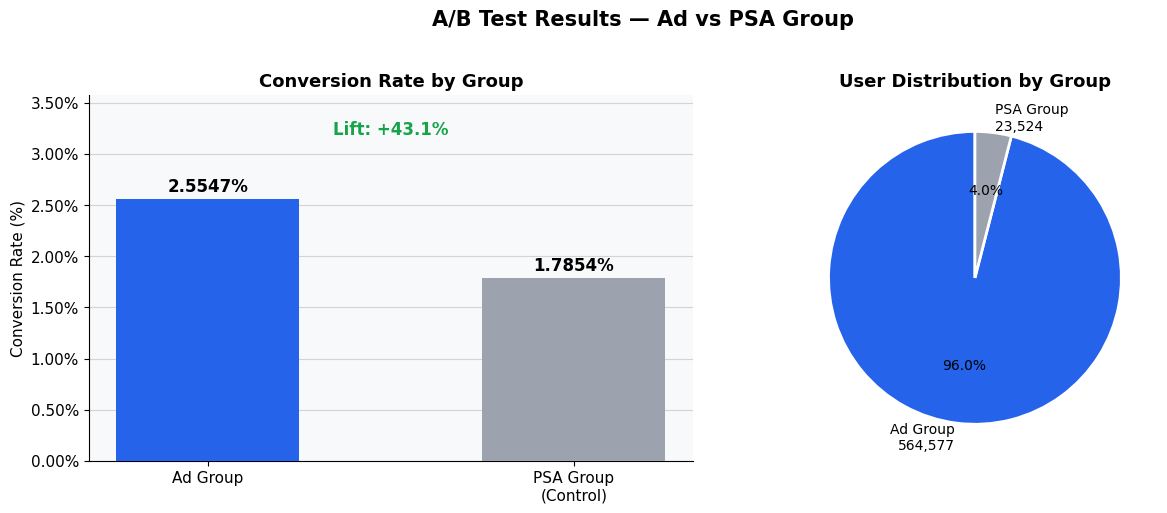

Saved: assets/chart1_cvr_comparison.png


In [9]:
#  Chart 1 — CVR Comparison 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('A/B Test Results — Ad vs PSA Group',
             fontsize=15, fontweight='bold', y=1.02)

groups     = ['Ad Group', 'PSA Group\n(Control)']
cvrs       = [ad_cvr * 100, psa_cvr * 100]
bar_colors = [COLORS['ad'], COLORS['psa']]

bars = axes[0].bar(groups, cvrs, color=bar_colors, width=0.5, zorder=3)
axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Conversion Rate (%)')
axes[0].set_ylim(0, max(cvrs) * 1.4)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
axes[0].grid(axis='y', alpha=0.5, zorder=0)

for bar, val in zip(bars, cvrs):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.04,
        f'{val:.4f}%',
        ha='center', va='bottom', fontweight='bold', fontsize=12
    )

axes[0].text(
    0.5, max(cvrs) * 1.25, f'Lift: +{lift:.1f}%',
    ha='center', transform=axes[0].transData,
    fontsize=12, color='#16A34A', fontweight='bold'
)

sizes  = [ad_n, psa_n]
labels = [f'Ad Group\n{ad_n:,}', f'PSA Group\n{psa_n:,}']
axes[1].pie(
    sizes, labels=labels, colors=bar_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 10}
)
axes[1].set_title('User Distribution by Group')

plt.tight_layout()
plt.savefig('assets/chart1_cvr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: assets/chart1_cvr_comparison.png")

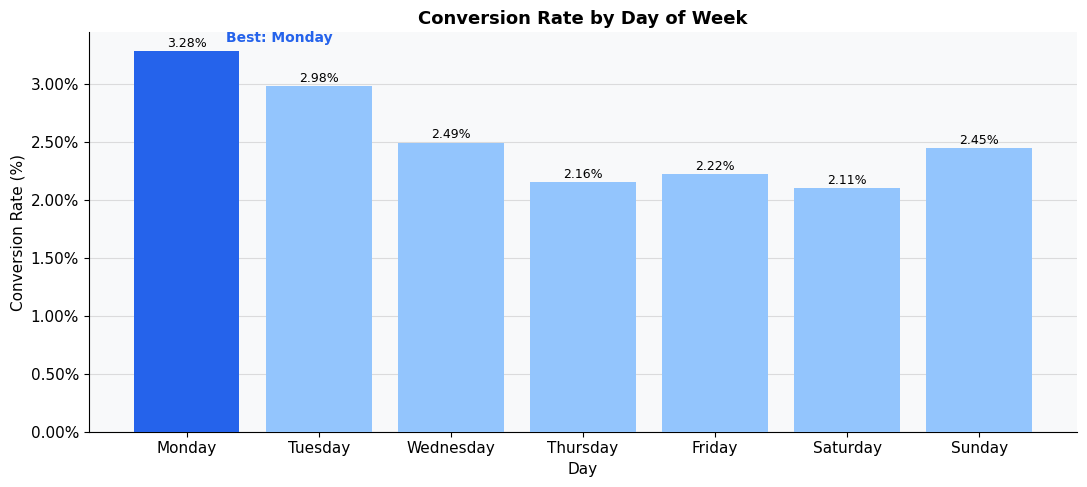

 Best day: Monday


In [10]:
# Chart 2 — Day of Week 
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']

day_cvr = (
    df.groupby('most_ads_day')
      .agg(users=('user_id', 'count'), converted=('converted', 'sum'))
      .assign(cvr=lambda x: x['converted'] / x['users'] * 100)
      .reindex(day_order)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors_day = [COLORS['ad'] if v == day_cvr['cvr'].max()
                  else '#93C5FD' for v in day_cvr['cvr']]
bars = ax.bar(day_cvr['most_ads_day'], day_cvr['cvr'],
              color=bar_colors_day, zorder=3)
ax.set_title('Conversion Rate by Day of Week')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Day')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.grid(axis='y', alpha=0.4, zorder=0)

for bar, val in zip(bars, day_cvr['cvr']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.2f}%', ha='center', va='bottom', fontsize=9
    )

best_day = day_cvr.loc[day_cvr['cvr'].idxmax(), 'most_ads_day']
ax.annotate(f'Best: {best_day}',
            xy=(day_cvr['cvr'].idxmax(), day_cvr['cvr'].max()),
            xytext=(day_cvr['cvr'].idxmax() + 0.3, day_cvr['cvr'].max() + 0.08),
            fontsize=10, color=COLORS['ad'], fontweight='bold')

plt.tight_layout()
plt.savefig('assets/chart2_day_cvr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Best day: {best_day}")

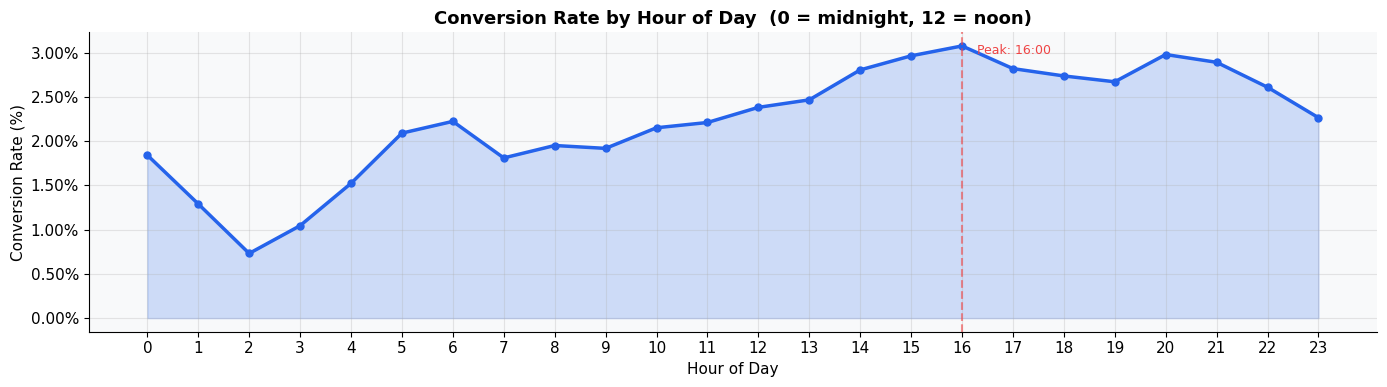

 Peak hour: 16:00


In [11]:
# Chart 3 — Hour of Day 
hour_cvr = (
    df.groupby('most_ads_hour')
      .agg(users=('user_id', 'count'), converted=('converted', 'sum'))
      .assign(cvr=lambda x: x['converted'] / x['users'] * 100)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(hour_cvr['most_ads_hour'], hour_cvr['cvr'],
                alpha=0.2, color=COLORS['ad'])
ax.plot(hour_cvr['most_ads_hour'], hour_cvr['cvr'],
        color=COLORS['ad'], linewidth=2.5, marker='o', markersize=5)

ax.set_title('Conversion Rate by Hour of Day  (0 = midnight, 12 = noon)')
ax.set_ylabel('Conversion Rate (%)')
ax.set_xlabel('Hour of Day')
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax.grid(alpha=0.3)

best_hour = int(hour_cvr.loc[hour_cvr['cvr'].idxmax(), 'most_ads_hour'])
ax.axvline(x=best_hour, color='#EF4444', linestyle='--', alpha=0.6)
ax.text(best_hour + 0.3, hour_cvr['cvr'].max() * 0.97,
        f'Peak: {best_hour}:00', color='#EF4444', fontsize=9)

plt.tight_layout()
plt.savefig('assets/chart3_hour_cvr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Peak hour: {best_hour}:00")

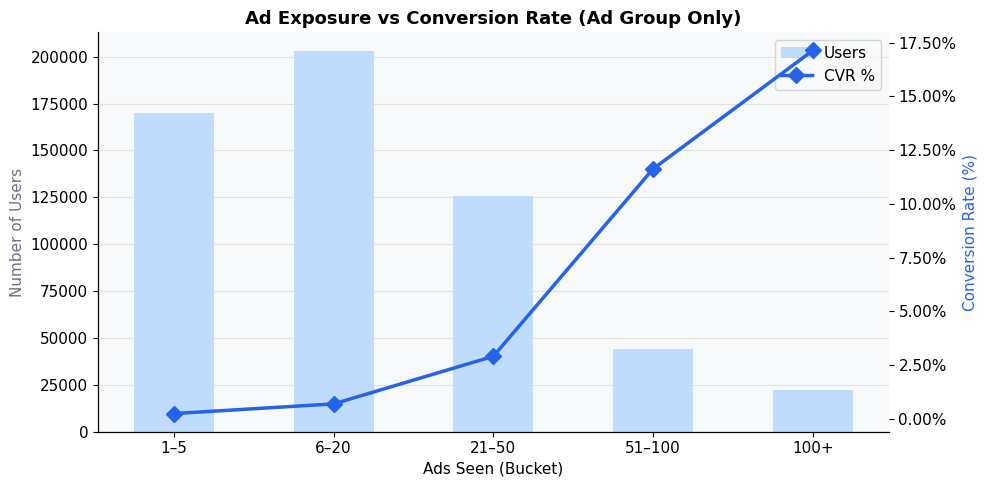

In [12]:
# Chart 4 — Ad Exposure Buckets 
bins     = [0, 5, 20, 50, 100, 2200]
labels_b = ['1–5', '6–20', '21–50', '51–100', '100+']

ad_only = df[df['test_group'] == 'ad'].copy()
ad_only['ad_bucket'] = pd.cut(ad_only['total_ads'],
                               bins=bins, labels=labels_b, right=True)

bucket_cvr = (
    ad_only.groupby('ad_bucket', observed=True)
           .agg(users=('user_id', 'count'), converted=('converted', 'sum'))
           .assign(cvr=lambda x: x['converted'] / x['users'] * 100)
           .reset_index()
)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
x = np.arange(len(bucket_cvr))

ax1.bar(x, bucket_cvr['users'], color='#BFDBFE', width=0.5,
        zorder=2, label='Users')
ax2.plot(x, bucket_cvr['cvr'], color=COLORS['ad'], linewidth=2.5,
         marker='D', markersize=8, zorder=3, label='CVR %')

ax1.set_xticks(x)
ax1.set_xticklabels(bucket_cvr['ad_bucket'])
ax1.set_xlabel('Ads Seen (Bucket)')
ax1.set_ylabel('Number of Users', color='#6B7280')
ax2.set_ylabel('Conversion Rate (%)', color=COLORS['ad'])
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax1.set_title('Ad Exposure vs Conversion Rate (Ad Group Only)')
ax1.grid(axis='y', alpha=0.3, zorder=0)

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='upper right')

plt.tight_layout()
plt.savefig('assets/chart4_ad_exposure.png', dpi=150, bbox_inches='tight')
plt.show()



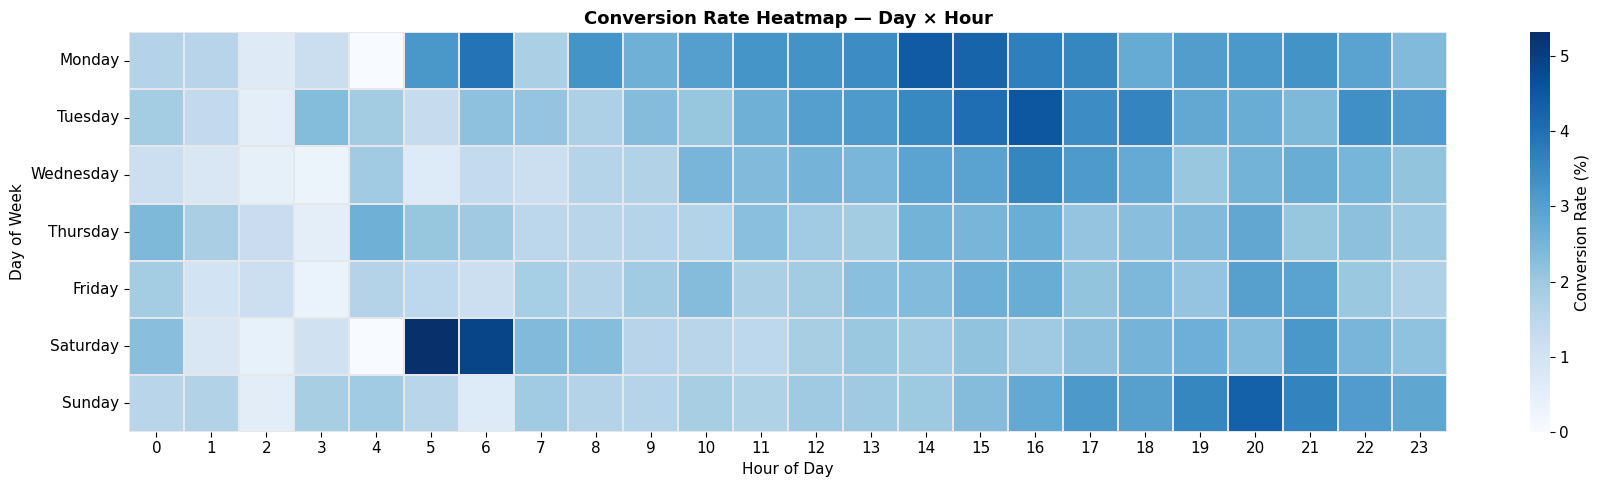

All 5 charts saved to assets/


In [13]:
# Chart 5 — Day × Hour Heatmap 
day_hour = (df.groupby(['most_ads_day', 'most_ads_hour'])
      .agg(users=('user_id', 'count'), converted=('converted', 'sum'))
      .assign(cvr=lambda x: x['converted'] / x['users'] * 100)
      .reset_index()
)

pivot = day_hour.pivot(index='most_ads_day',
                       columns='most_ads_hour', values='cvr')
pivot = pivot.reindex(['Monday', 'Tuesday', 'Wednesday',
                       'Thursday', 'Friday', 'Saturday', 'Sunday'])

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(pivot, cmap='Blues', ax=ax,
            linewidths=0.3, linecolor='#E5E7EB',
            annot=False,
            cbar_kws={'label': 'Conversion Rate (%)'})
ax.set_title('Conversion Rate Heatmap — Day × Hour', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('assets/chart5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("All 5 charts saved to assets/")

In [14]:
#Final Summary
print("\n" + "=" * 58)
print("       A/B TEST ANALYSIS — EXECUTIVE SUMMARY")
print("=" * 58)
print(f"  Total users analysed      : {len(df):,}")
print(f"  Ad group users            : {ad_n:,}")
print(f"  PSA group users           : {psa_n:,}")
print()
print(f"  Ad group CVR              : {ad_cvr*100:.4f}%")
print(f"  PSA group CVR (control)   : {psa_cvr*100:.4f}%")
print(f"  Relative lift             : +{lift:.2f}%")
print()
print(f"  Chi² statistic            : {chi2:.4f}")
print(f"  p-value                   : {p_value:.2e}")
print(f"  Statistically significant : {'YES ' if p_value < 0.05 else 'NO '}")
print()
print("  RECOMMENDATION")
print("  " + "─" * 54)
print(f"  Ads produced a +{lift:.1f}% relative lift in conversion")
print("  rate vs control. Result is statistically significant")
print("  at 95% confidence level (p < 0.001).")
print("  → Continue the ad campaign.")
print("  → Concentrate ad spend on weekends, 16:00–22:00.")
print("=" * 58)



       A/B TEST ANALYSIS — EXECUTIVE SUMMARY
  Total users analysed      : 588,101
  Ad group users            : 564,577
  PSA group users           : 23,524

  Ad group CVR              : 2.5547%
  PSA group CVR (control)   : 1.7854%
  Relative lift             : +43.09%

  Chi² statistic            : 54.0058
  p-value                   : 2.00e-13
  Statistically significant : YES 

  RECOMMENDATION
  ──────────────────────────────────────────────────────
  Ads produced a +43.1% relative lift in conversion
  rate vs control. Result is statistically significant
  at 95% confidence level (p < 0.001).
  → Continue the ad campaign.
  → Concentrate ad spend on weekends, 16:00–22:00.
